# Wildfire Occurrence Model
**Research question:** Can weather conditions and satellite-derived vegetation dryness predict wildfire occurrence in Southern California over a given time horizon? **Data sources:** GridMET (weather, fire-danger indices), MODIS/NDVI via Google Earth Engine (vegetation), CAL FIRE/FRAP (fire occurrence labels, LA County 2000-2025), Open-Elevation (topography, slope/aspect derived by hand from raw elevation). **A note on the API-pull loop cells:** building the positive (real fire) and negative (non-fire) example sets required looping over 373 locations each, making thousands of real API calls (GridMET, Open-Elevation, Earth Engine). That data has already been pulled, verified, and saved to a checkpoint CSV. The loop code is left in this notebook, commented out, so the full data-engineering process is visible and explainable, but it does not re-run automatically. The notebook loads the saved checkpoint file directly instead. **Structure:** 1. Setup 2. Elevation API & the slope/aspect function (derived by hand from raw elevation) 3. Sourcing fire occurrence data (CAL FIRE) 4. GridMET weather pull & feature engineering (single test point) 5. NDVI via Google Earth Engine 6. Building the reusable per-location feature functions 7. Building the full dataset (positive & negative examples) — code shown, not re-run 8. Loading the saved checkpoint dataset 9. EDA 10. Modeling 11. Prediction function

Rather than explicitly trying to define wildfire risk through a set of self-chosen thresholds, this project uses actual, recorded wildfire occurence as the prediction target. In order to accomplish this, the models were trained on data describing its fuel sources, weather, and topography at specfic data and location where a fire occured. By pulling from a ground truth, that being a fire occurence, rather than a self-chosen threshold, the model has to learn the relationships between physical conditions and what actually happened.

## 1. Setup

In [ ]:
%pip install pygridmet
%pip install earthengine-api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.7 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
import ee
ee.Authenticate()
ee.Initialize(project='wildfire-occurance-model')

In [ ]:
import pandas as pd
import pygridmet as gridmet
gridmet.GridMET().gridmet_table

,variable,abbr,long_name,units
0,Precipitation,pr,precipitation_amount,mm
1,Maximum Relative Humidity,rmax,daily_maximum_relative_humidity,%
2,Minimum Relative Humidity,rmin,daily_minimum_relative_humidity,%
3,Specific Humidity,sph,daily_mean_specific_humidity,kg/kg
4,Surface Radiation,srad,daily_mean_shortwave_radiation_at_surface,W/m2
5,Wind Direction,th,daily_mean_wind_direction,Degrees clockwise from north
6,Minimum Air Temperature,tmmn,daily_minimum_temperature,K
7,Maximum Air Temperature,tmmx,daily_maximum_temperature,K
8,Wind Speed,vs,daily_mean_wind_speed,m/s
9,Burning Index,bi,daily_mean_burning_index_g,-


## 2. Elevation API & Building the Slope/Aspect Function
Working out the Open-Elevation API and the 5-point (center + N/S/E/W) sampling approach on a single test point, before generalizing it into a reusable function. Slope and aspect are derived from raw elevation using a discrete gradient: partial derivatives approximated via finite differences (accounting for the fact that a degree of longitude covers less real distance than a degree of latitude, at this latitude), then combined into a magnitude (slope) and a compass-bearing angle (aspect).

In [ ]:
#requests fetches API for us.
import requests
response = requests.get("https://api.open-elevation.com/api/v1/lookup?locations=34,-118")
response.json()

data = response.json()
elevation = data['results'][0]['elevation']
print(response.json())

long = data['results'][0]['longitude']
lat = data['results'][0]['latitude']
print(elevation)
print(long)
print(lat)
north_point = (lat + 0.01, long)
south_point = (lat - 0.01, long)
east_point = (lat, long + 0.01)
west_point = (lat, long - 0.01)
print(north_point)
print(south_point)
print(east_point)
print(west_point)
points = [north_point, south_point, east_point, west_point]
point_elevations = []
for point in points:
  response = requests.get(f"https://api.open-elevation.com/api/v1/lookup?locations={point[0]},{point[1]}")
  data = response.json()
  elevation = data['results'][0]['elevation']
  point_elevations.append(elevation)
print(point_elevations)

{'results': [{'latitude': 34.0, 'longitude': -118.0, 'elevation': 307.0}]}
307.0
-118.0
34.0
(34.01, -118.0)
(33.99, -118.0)
(34.0, -117.99)
(34.0, -118.01)
[222.0, 361.0, 225.0, 321.0]


Generalized into a reusable function. Verified against the hand-calculated slope/aspect for the (34, -118) test point before trusting it on real data.

In [ ]:
from IPython.core.interactiveshell import dis
import numpy as np

def get_slope_aspect(lat, long, offset = 0.01):
  north_point = (lat + offset, long)
  south_point = (lat - offset, long)
  east_point = (lat, long + offset)
  west_point = (lat, long - offset)
  points = [north_point, south_point, east_point, west_point]
  point_elevations = []
  for point in points:
    response = requests.get(f"https://api.open-elevation.com/api/v1/lookup?locations={point[0]},{point[1]}")
    data = response.json()
    elevation = data['results'][0]['elevation']
    point_elevations.append(elevation)
  ns_partial = (point_elevations[0] - point_elevations[1]) / (2 * offset * 111000)
  ew_partial = (point_elevations[2] - point_elevations[3]) / (2 * offset * 111000 * np.cos(np.radians(lat)))
  slope = np.sqrt(ns_partial**2 + ew_partial**2)
  aspect = np.arctan2(-ns_partial, -ew_partial) * 180 / np.pi
  if aspect < 0:
    aspect += 360
  return slope, aspect
get_slope_aspect(34, -118)

(np.float64(0.08149285752080422), np.float64(50.203287412610656))

## 3. Sourcing Fire Occurrence Data (CAL FIRE / FRAP)Queried CAL FIRE's ArcGIS REST API for LA County (`UNIT_ID = 'LAC'`) fires from 2000 onward. The full, unbatched query hit a malformed-geometry parsing error on the large response; batching the request with `resultOffset`/`resultRecordCount` and wrapping each batch in `try`/`except` isolated the issue and recovered a complete, clean pull (374 of 375 records).

In [ ]:
import geopandas as gpd
chunks = []
offset = 0
batch_size = 100

for offset in range(0, 375, batch_size):
    url = f"https://services1.arcgis.com/jUJYIo9tSA7EHvfZ/arcgis/rest/services/California_Historic_Fire_Perimeters/FeatureServer/0/query?where=UNIT_ID+%3D+%27LAC%27+AND+YEAR_+%3E%3D+2000&outFields=*&returnGeometry=true&resultRecordCount={batch_size}&resultOffset={offset}&f=geojson"
    try:
        chunk = gpd.read_file(url)
        chunks.append(chunk)
        print(f"Offset {offset}: success, {len(chunk)} records")
    except Exception as e:
        print(f"Offset {offset}: FAILED - {e}")

Offset 0: success, 100 records
Offset 100: success, 100 records
Offset 200: success, 100 records
Offset 300: success, 75 records


Merge batches, extract each fire's centroid (representative point from its polygon), and convert `ALARM_DATE` from Unix milliseconds to a real datetime.

In [ ]:
fires_lac = pd.concat(chunks, ignore_index=True)
fires_lac.shape
fires_lac['YEAR_'].max()
fires_lac['YEAR_'].min()
fires_lac['centroid'] = fires_lac.geometry.centroid
fires_lac['ALARM_DATE'] = pd.to_datetime(fires_lac['ALARM_DATE'], unit='ms')
fires_lac.head()

/tmp/ipykernel_727/3356754299.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  fires_lac['centroid'] = fires_lac.geometry.centroid


,OBJECTID,YEAR_,STATE,AGENCY,UNIT_ID,FIRE_NAME,INC_NUM,IRWINID,ALARM_DATE,CONT_DATE,...,COMMENTS,COMPLEX_NAME,COMPLEX_ID,FIRE_NUM,GlobalID,DECADES,Shape__Area,Shape__Length,geometry,centroid
0,8,2025,CA,CDF,LAC,EATON,00009087,{72660ADC-B5EF-4D96-A33F-B4EA3740A4E3},2025-01-08,1.738282e+12,...,None,None,None,None,d8dcb0e7-0ad6-46a4-901a-86d777bb09af,2020-2025,8.336393e+07,104933.207224,"MULTIPOLYGON (((-118.10094 34.16681, -118.1009...",POINT (-118.09261 34.20078)
1,50,2025,CA,USF,LAC,KING,00282478,{821F8646-A801-49C0-9056-E17985DD0C4C},2025-08-14,1.755389e+12,...,unified command (ANF),None,None,None,365c6d51-73f2-494b-9a2b-3a63df9acac5,2020-2025,3.464734e+06,10531.729139,"MULTIPOLYGON (((-118.78448 34.70076, -118.7845...",POINT (-118.79126 34.71242)
2,54,2025,CA,CCO,LAC,HAWK,00300879,{A00A1227-0BB1-49E8-92CD-63106E184E06},2025-08-14,1.755389e+12,...,Alt inc num 283143,None,None,None,e2c6b2e7-a0be-494e-ac73-fc2309c17c56,2020-2025,2.871298e+06,12227.078256,"POLYGON ((-118.21729 34.54268, -118.21743 34.5...",POINT (-118.22188 34.54193)
3,70,2025,CA,CDF,LAC,LIDIA,00010648,{E451AEAE-4177-4B78-BDE8-1E27B9D5D56C},2025-01-08,1.736554e+12,...,None,None,None,None,4523d61f-2fb5-4b4e-8a25-ae32f4326853,2020-2025,2.073567e+06,11177.246538,"POLYGON ((-118.25563 34.43419, -118.25547 34.4...",POINT (-118.24683 34.43484)
4,342,2025,CA,CCO,LAC,HAROLD,00357703,{0F2651BC-9451-4577-A52D-1F38D0DCC571},2025-10-12,1.760486e+12,...,None,None,None,None,bc750485-be6c-4faf-b91d-01719a5180ca,2020-2025,6.721450e+04,1305.748982,"POLYGON ((-118.61483 34.3053, -118.61607 34.30...",POINT (-118.61561 34.30633)


## 4. GridMET Weather Pull & Feature Engineering (Single Test Point)
Built and validated all weather-derived features on one fixed test point (34, -118) before generalizing to per-fire locations: a water-balance drought term (`pr - pet`, rolled over 30- and 90-day windows), month/seasonality, a `days_since_rain` counter (cumsum → groupby → cumcount pattern), and a Santa Ana wind flag (direction + humidity thresholds), validated against real NWS/climatology sources.

In [ ]:
grid_data = gridmet.get_bycoords((-118,34,), ("2000-02-18","2026-01-01"), variables=["tmmx", "rmin", "vs", "vpd","pr","pet","erc","fm100","fm1000","th"])


/usr/local/lib/python3.12/dist-packages/pygridmet/pygridmet.py:161: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'day' ('day',) The recommendation is to set join explicitly for this case.
  clm = xr.merge(_open_dataset(f) for f in clm_all_files).astype("f4")
/usr/local/lib/python3.12/dist-packages/pygridmet/pygridmet.py:161: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  clm = xr.merge(_open_dataset(f) for f in clm_all_file

In [ ]:
#drought feature creation
df_drought = gridmet.get_bycoords((-118,34,), ("2019-01-01","2026-01-01"), variables=["pr","pet"])
df_drought["Drought (mm)"] = df_drought["pr (mm)"] - df_drought["pet (mm)"]
df_drought['Drought (mm)'].rolling(window=30).sum()
grid_data['Drought_30days'] = df_drought['Drought (mm)'].rolling(window=30).sum()
grid_data['Drought_90days'] = df_drought['Drought (mm)'].rolling(window=90).sum()

#season
grid_data["month"] = grid_data.index.month #implement cyclical sin or cos


#days since rain
is_rain = grid_data["pr (mm)"] > 1
grid_data["cumsum"] = is_rain.cumsum()
grid_data["days_since_rain"] = grid_data["cumsum"].groupby(grid_data["cumsum"]).cumcount()

#santa ana winds
grid_data
is_santa_direction = (grid_data["th (Degrees clockwise from north)"] >= 45) & (grid_data["th (Degrees clockwise from north)"] <= 90)
is_santa_humidity = grid_data["rmin (%)"] < 20.0
santa_ana_flag = (is_santa_direction) & (is_santa_humidity)
grid_data["santa_ana_flag"] = santa_ana_flag

grid_data.groupby('month')['santa_ana_flag'].sum()
grid_data











/usr/local/lib/python3.12/dist-packages/pygridmet/pygridmet.py:161: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'day' ('day',) The recommendation is to set join explicitly for this case.
  clm = xr.merge(_open_dataset(f) for f in clm_all_files).astype("f4")
/usr/local/lib/python3.12/dist-packages/pygridmet/pygridmet.py:161: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  clm = xr.merge(_open_dataset(f) for f in clm_all_file

,tmmx (K),rmin (%),vs (m/s),vpd (kPa),pr (mm),pet (mm),erc (-),fm100 (%),fm1000 (%),th (Degrees clockwise from north),Drought_30days,Drought_90days,month,cumsum,days_since_rain,santa_ana_flag
time,,,,,,,,,,,,,,,,
2000-02-18,293.399994,35.599998,1.3,0.78,0.000000,2.2,23.0,20.100000,19.700001,108.0,NaN,NaN,2,0,0,False
2000-02-19,293.799988,30.400000,3.2,0.91,1.500000,2.9,17.0,17.400000,19.299999,133.0,NaN,NaN,2,1,0,False
2000-02-20,289.700012,31.200001,6.9,0.42,20.400000,2.2,13.0,20.299999,20.400000,120.0,NaN,NaN,2,2,0,False
2000-02-21,288.899994,56.099998,6.4,0.38,35.900002,2.1,8.0,22.700001,21.500000,155.0,NaN,NaN,2,3,0,False
2000-02-22,290.600006,59.799999,1.7,0.45,0.900000,1.8,9.0,21.900000,21.600000,147.0,NaN,NaN,2,3,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-28,292.899994,24.400000,2.8,0.99,0.000000,2.5,26.0,18.700001,19.100000,19.0,36.599998,81.499998,12,737,2,False
2025-12-29,296.200012,11.200000,3.7,1.54,0.000000,3.8,32.0,14.700000,18.799999,39.0,34.399998,80.899998,12,737,3,False
2025-12-30,295.799988,20.400000,2.9,1.51,0.000000,3.2,34.0,12.200000,18.200001,52.0,32.599998,81.199998,12,737,4,False


## 5. Exploration — NDVI via Google Earth EngineMODIS NDVI is raw satellite imagery, not a pre-gridded product like GridMET, so it needs an explicit choice of how to reduce many pixels to one value. Used a buffered spatial mean (~2km radius) to roughly match GridMET's native resolution, rather than a single raw pixel. Values come back scaled by 10,000 and are divided down to the real -1 to 1 NDVI range.

In [ ]:
# filtering NVDI Google Earth data by location and date
nvdi_collection = ee.ImageCollection('MODIS/061/MOD13Q1')
# print(nvdi_collection.size().getInfo())
point = ee.Geometry.Point([-118,34])
filtered = nvdi_collection.filterDate('2019-01-01','2020-01-01').filterBounds(point)
print(filtered.size().getInfo())

#gives values 10^4 larger
image = filtered.first()
value = image.select('NDVI').reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry = point.buffer(2000),
    scale=250
).get('NDVI').getInfo()
print(value)

#time
image_list = filtered.toList(filtered.size())
n = image_list.size().getInfo()
print(n)
dates = []
ndvi_values = []
for i in range(n):
  img = ee.Image(image_list.get(i))
  date = img.date().format('YYYY-MM-dd').getInfo()
  dates.append(date)
  ndvi = img.select('NDVI').reduceRegion(
      reducer=ee.Reducer.mean(),
      geometry = point.buffer(2000),
      scale = 250
  ).get('NDVI').getInfo()
  ndvi_values.append(ndvi)


print(dates)
print(ndvi_values)

print(len(dates))
print(len(ndvi_values))
ndvi_df = pd.DataFrame({'date':dates,  'NDVI':ndvi_values})
ndvi_df['NDVI'] = ndvi_df['NDVI']/10000


23
4320.669358500996
23
['2019-01-01', '2019-01-17', '2019-02-02', '2019-02-18', '2019-03-06', '2019-03-22', '2019-04-07', '2019-04-23', '2019-05-09', '2019-05-25', '2019-06-10', '2019-06-26', '2019-07-12', '2019-07-28', '2019-08-13', '2019-08-29', '2019-09-14', '2019-09-30', '2019-10-16', '2019-11-01', '2019-11-17', '2019-12-03', '2019-12-19']
[4320.669358500996, 4798.0014808379565, 5586.837553325961, 5417.045603570869, 5971.875375256759, 6079.255312845633, 5751.321121030181, 5590.465555379997, 5143.623439721915, 5193.973633275399, 5008.323036814665, 4521.578803918473, 4391.747491704853, 4222.416455996209, 4071.9271409385365, 3968.4234673724145, 3946.451591878657, 3936.9402946753053, 3944.4785313635653, 4028.0402393034124, 4159.965012735204, 4528.040541874838, 4771.952072513281]
23
23


Generalized into a reusable function: `get_ndvi_feature(lat, lon, target_date)`. NDVI composites only update every 16 days, so rather than requiring an exact-date match, this searches a 32-day window before the target date and takes the most recent available composite (leak-safe — never looks past the target date).

In [ ]:
def get_ndvi_feature(lat, lon, target_date, search_window_days=32):
    point = ee.Geometry.Point([lon, lat])
    end = pd.to_datetime(target_date).strftime("%Y-%m-%d")
    start = (pd.to_datetime(target_date) - pd.Timedelta(days=search_window_days)).strftime("%Y-%m-%d")

    nvdi_collection = ee.ImageCollection('MODIS/061/MOD13Q1')
    filtered = nvdi_collection.filterDate(start, end).filterBounds(point)

    image = filtered.sort('system:time_start', False).first()  # most recent image in the window

    value = image.select('NDVI').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=point.buffer(2000),
        scale=250
    ).get('NDVI').getInfo()

    return value / 10000

get_ndvi_feature(34.20078476275709, -118.09260810469993, "2025-01-08")

0.5334996327086747

## 6. Building the Reusable Weather/Fire-Danger Feature Function
Generalizing the single-test-point weather/feature logic above into `get_gritmet_features(lat, lon, target_date)`: pulls a ~120-day GridMET window ending at `target_date` (enough runway for the 90-day rolling drought window), computes the same engineered features, and returns just the target date's row. Also includes a spot-check here, cross-referencing the first fire (Eaton) against the original single-point test data.

In [ ]:
centroid = fires_lac['centroid'][0]
fire_date = fires_lac['ALARM_DATE'][0]
print(centroid)
print(fire_date)
grid_fire_date = grid_data.loc[grid_data.index == fire_date]
print(grid_fire_date)
get_slope_aspect(centroid.y, centroid.x)

def get_gritmet_features(lat, lon, target_date, lookback_days=120):
  start_date = (pd.to_datetime(target_date) - pd.Timedelta(days=lookback_days)).strftime('%Y-%m-%d')
  end_date = pd.to_datetime(target_date).strftime('%Y-%m-%d')
  grid_data = gridmet.get_bycoords((lon,lat), (start_date, end_date), variables=["tmmx", "rmin", "vs", "vpd","pr","pet","erc","fm100","fm1000","th"])
  grid_data["Drought (mm)"] = grid_data["pr (mm)"] - grid_data["pet (mm)"]
  grid_data['Drought_30days'] = grid_data['Drought (mm)'].rolling(window=30).sum()
  grid_data['Drought_90days'] = grid_data['Drought (mm)'].rolling(window=90).sum()
  grid_data["month"] = grid_data.index.month
  is_rain = grid_data["pr (mm)"] > 1
  grid_data["cumsum"] = is_rain.cumsum()
  grid_data["days_since_rain"] = grid_data["cumsum"].groupby(grid_data["cumsum"]).cumcount()
  is_santa_direction = (grid_data["th (Degrees clockwise from north)"] >= 45) & (grid_data["th (Degrees clockwise from north)"] <= 90)
  is_santa_humidity = grid_data["rmin (%)"] < 20.0
  santa_ana_flag = (is_santa_direction) & (is_santa_humidity)
  grid_data["santa_ana_flag"] = santa_ana_flag
  row = grid_data.loc[grid_data.index == pd.to_datetime(target_date)]
  return row

get_gritmet_features(34.20078476275709, -118.09260810469993, "2025-01-08")


POINT (-118.09260810469993 34.20078476275709)
2025-01-08 00:00:00
              tmmx (K)  rmin (%)  vs (m/s)  vpd (kPa)  pr (mm)  pet (mm)  \
time                                                                       
2025-01-08  296.200012       7.4       4.6       1.84      0.0       4.9   

            erc (-)  fm100 (%)  fm1000 (%)  th (Degrees clockwise from north)  \
time                                                                            
2025-01-08     68.0        6.8        10.7                               13.0   

            Drought_30days  Drought_90days  month  cumsum  days_since_rain  \
time                                                                         
2025-01-08           -60.9     -210.999999      1     708               45   

            santa_ana_flag  
time                        
2025-01-08           False  


/usr/local/lib/python3.12/dist-packages/pygridmet/pygridmet.py:161: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'day' ('day',) The recommendation is to set join explicitly for this case.
  clm = xr.merge(_open_dataset(f) for f in clm_all_files).astype("f4")
/usr/local/lib/python3.12/dist-packages/pygridmet/pygridmet.py:161: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  clm = xr.merge(_open_dataset(f) for f in clm_all_file

,tmmx (K),rmin (%),vs (m/s),vpd (kPa),pr (mm),pet (mm),erc (-),fm100 (%),fm1000 (%),th (Degrees clockwise from north),Drought (mm),Drought_30days,Drought_90days,month,cumsum,days_since_rain,santa_ana_flag
time,,,,,,,,,,,,,,,,,
2025-01-08,291.700012,6.2,5.4,1.5,0.0,4.8,88.0,5.3,6.6,23.0,-4.8,-70.0,-226.299999,1,4,1,False


**Verification:** `days_since_rain = 1` for Eaton's fire date initially looked inconsistent with a value seen earlier on the single-point test data — but those were two different dates entirely, not a contradiction. Checked the raw daily `pr` values directly and confirmed real rain (1.1mm) did occur exactly one day before Eaton's alarm date, so `days_since_rain = 1` is genuinely correct.

In [ ]:
start_date = (pd.to_datetime(fire_date) - pd.Timedelta(days=120)).strftime("%Y-%m-%d")
check_data = gridmet.get_bycoords((centroid.x, centroid.y), (start_date, "2025-01-08"), variables=["pr"])
check_data.tail(10)

/usr/local/lib/python3.12/dist-packages/pygridmet/pygridmet.py:161: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'day' ('day',) The recommendation is to set join explicitly for this case.
  clm = xr.merge(_open_dataset(f) for f in clm_all_files).astype("f4")
/usr/local/lib/python3.12/dist-packages/pygridmet/pygridmet.py:161: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  clm = xr.merge(_open_dataset(f) for f in clm_all_file

,pr (mm)
time,
2024-12-29,0.0
2024-12-30,0.0
2025-01-01,0.0
2025-01-02,0.0
2025-01-03,0.0
2025-01-04,0.0
2025-01-05,0.0
2025-01-06,0.0
2025-01-07,1.1


## 7. Building the Full Dataset — Positive Examples (Real Fires)**This code is commented out and does not re-run in this notebook** — it made ~2,000+ real API calls across 373 fires the first time it ran, which is preserved here so the data-engineering process is fully visible and explainable, not to be re-executed. Loop over all 375 LA County fires: pull weather/drought/fire-danger features (`get_gritmet_features`), topography (`get_slope_aspect`), and NDVI for each fire's centroid and actual alarm date. Each row is labeled `1`. Wrapped in `try`/`except` so one bad location doesn't lose the whole run — 373 of 375 fires completed successfully (374 in an earlier pass before NDVI was added).

In [ ]:
# results = []
# for idx, fire in fires_lac.iterrows():
#   lat = fire['centroid'].y
#   lon = fire['centroid'].x
#   date = fire['ALARM_DATE']

#   try:
#     weather_row = get_gritmet_features(lat, lon, date)
#     slope, aspect = get_slope_aspect(lat, lon)

#     combined = weather_row.copy()
#     combined['slope'] = slope
#     combined['aspect'] = aspect
#     combined['label'] = 1
#     combined['fire_name'] = fire['FIRE_NAME']

#     combined['lat'] = lat
#     combined['lon'] = lon
#     combined['date'] = date  # or random_date for the negative loop
#     combined['ndvi'] = get_ndvi_feature(lat, lon, date)

#     results.append(combined)
#     print(f"{idx}: success - {fire['FIRE_NAME']}")
#   except Exception as e:
#     print(f"{idx}: FAILED - {fire['FIRE_NAME']} - {e}")

In [ ]:
# fires_features = pd.concat(results, ignore_index=True)
# fires_features.shape


Verification pass on the positive set (all commented — reflects checks run on the original, in-memory result).

In [ ]:
# fires_features['label'].value_counts()
# fires_features.isna().sum()

In [ ]:
# fires_features['label'].value_counts()
# fires_features.isna().sum()
# fires_features[['slope', 'aspect', 'month', 'days_since_rain', 'santa_ana_flag']].describe()

In [ ]:
# fires_features.isna().sum()


In [ ]:
# fires_features['label'].value_counts()



## 8. Building the Full Dataset — Negative Examples (Non-Fire Dates)**Also commented out for the same reason.** For each fire's same location, sample a random date from a different year than the actual fire, and pull the same features for that (location, non-fire-date) pair, labeled `0`. This keeps geography constant between positive and negative examples while varying only time.

In [ ]:
import random

# negative_results = []

# for idx, fire in fires_lac.iterrows():
#   lat = fire['centroid'].y
#   lon = fire['centroid'].x
#   fire_year = fire['ALARM_DATE'].year

#   possible_years = [y for y in range(2000, 2026) if y != fire_year]
#   random_year = random.choice(possible_years)
#   random_month = random.randint(1, 12)
#   random_day = random.randint(1, 28)
#   random_date = pd.Timestamp(year=random_year, month=random_month, day=random_day)

#   try:
#     weather_row = get_gritmet_features(lat, lon, random_date)
#     slope, aspect = get_slope_aspect(lat, lon)

#     combined = weather_row.copy()
#     combined['slope'] = slope
#     combined['aspect'] = aspect
#     combined['label'] = 0
#     combined['fire_name'] = fire['FIRE_NAME']

#     combined['lat'] = lat
#     combined['lon'] = lon
#     combined['date'] = random_date
#     combined['ndvi'] = get_ndvi_feature(lat, lon, date)

#     negative_results.append(combined)
#     print(f"{idx}: success - {fire['FIRE_NAME']} (negative, {random_date.date()})")
#   except Exception as e:
#     print(f"{idx}: FAILED - {fire['FIRE_NAME']} - {e}")

In [ ]:
# negative_features = pd.concat(negative_results, ignore_index=True)
# negative_features.shape


In [ ]:
# print(negative_features['label'].value_counts())
# print(negative_features.isna().sum())
# negative_features[['slope', 'aspect', 'month', 'days_since_rain', 'santa_ana_flag']].describe()


## 9. Final Dataset Assembly & Loading the CheckpointCombine positive and negative examples into one balanced, fully-verified dataset (commented — reflects the original build). The actual, current data is loaded below from the saved checkpoint CSV in Google Drive, so nothing above needs to be re-run.

In [ ]:
# full_dataset = pd.concat([fires_features, negative_features], ignore_index=True)
# full_dataset.shape

In [ ]:
# full_dataset.to_csv("wildfire_full_dataset.csv", index=False)

# from google.colab import files
# files.download("wildfire_full_dataset.csv")
from google.colab import drive
drive.mount('/content/drive')
# full_dataset = pd.read_csv("wildfire_full_dataset (3).csv")
# full_dataset.shape

Mounted at /content/drive


Load the saved, verified dataset: this is the real starting point for everything below.

In [ ]:
full_dataset = pd.read_csv('/content/drive/MyDrive/wildfire_full_dataset (3).csv')
full_dataset.to_csv('/content/drive/MyDrive/wildfire_full_dataset (3).csv', index=False)

## 10. Exploratory Data Analysis

In [ ]:
full_dataset.index

RangeIndex(start=0, stop=746, step=1)

In [ ]:
full_dataset.head()

,tmmx (K),rmin (%),vs (m/s),vpd (kPa),pr (mm),pet (mm),erc (-),fm100 (%),fm1000 (%),th (Degrees clockwise from north),...,days_since_rain,santa_ana_flag,slope,aspect,label,fire_name,lat,lon,date,ndvi
0,291.7,6.2,5.4,1.50,0.0,4.8,88.0,5.3,6.6,23.0,...,1,False,0.312207,228.612346,1,EATON,34.200785,-118.092608,2025-01-08,0.533500
1,304.3,14.0,3.7,2.45,0.0,7.6,95.0,4.4,5.0,230.0,...,105,False,0.041432,253.083982,1,KING,34.712419,-118.791258,2025-08-14,0.274013
2,301.9,16.6,3.2,2.18,0.0,6.8,90.0,5.1,5.7,239.0,...,89,False,0.139001,299.716399,1,HAWK,34.541927,-118.221880,2025-08-14,0.273571
3,297.7,26.3,2.9,1.15,0.0,3.8,53.0,10.9,12.1,147.0,...,24,False,0.046044,261.143397,1,HAROLD,34.306331,-118.615613,2025-10-12,0.425441
4,299.6,12.9,3.3,1.99,0.0,7.1,76.0,6.2,8.5,262.0,...,62,False,0.019886,305.365361,1,POST,34.726406,-118.834158,2024-06-15,0.328103


In [ ]:
full_dataset.shape

(746, 25)

### Wave 1 — Data Quality & IntegrityConfirming the joined dataset is actually correct before interpreting anything: label balance, missing values, and plausible ranges across the key engineered features.

In [ ]:
print(full_dataset['label'].value_counts())
print(full_dataset.isna().sum())
full_dataset[['slope', 'aspect', 'month', 'days_since_rain', 'santa_ana_flag', 'ndvi']].describe()

label
1    373
0    373
Name: count, dtype: int64
tmmx (K)                             0
rmin (%)                             0
vs (m/s)                             0
vpd (kPa)                            0
pr (mm)                              0
pet (mm)                             0
erc (-)                              0
fm100 (%)                            0
fm1000 (%)                           0
th (Degrees clockwise from north)    0
Drought (mm)                         0
Drought_30days                       0
Drought_90days                       0
month                                0
cumsum                               0
days_since_rain                      0
santa_ana_flag                       0
slope                                0
aspect                               0
label                                0
fire_name                            0
lat                                  0
lon                                  0
date                                 0
ndvi          

,slope,aspect,month,days_since_rain,ndvi
count,746.000000,746.000000,746.000000,746.000000,746.000000
mean,0.070622,180.760739,6.729223,43.402145,0.338878
std,0.048749,104.449472,2.972650,40.656283,0.103660
min,0.002837,-0.000000,1.000000,0.000000,0.109961
25%,0.036518,78.877041,5.000000,9.000000,0.260712
50%,0.058921,185.353074,7.000000,28.000000,0.315087
75%,0.094139,273.679837,9.000000,72.000000,0.411882
max,0.312207,358.979349,12.000000,120.000000,0.736555


### Wave 2 — Univariate & Bivariate (Feature vs. Label)Label-split histograms double as both univariate (each feature's own shape) and bivariate (does that shape differ by fire/non-fire) analysis — the more useful combined view for a classification problem, rather than a single label-blind histogram per feature.

,tmmx (K)
,rmin (%)
,vs (m/s)
,vpd (kPa)
,Drought_30days
,Drought_90days
,days_since_rain
,ndvi
,slope
label,
0,"[[Axes(0.125,0.666111;0.215278x0.213889), Axes..."


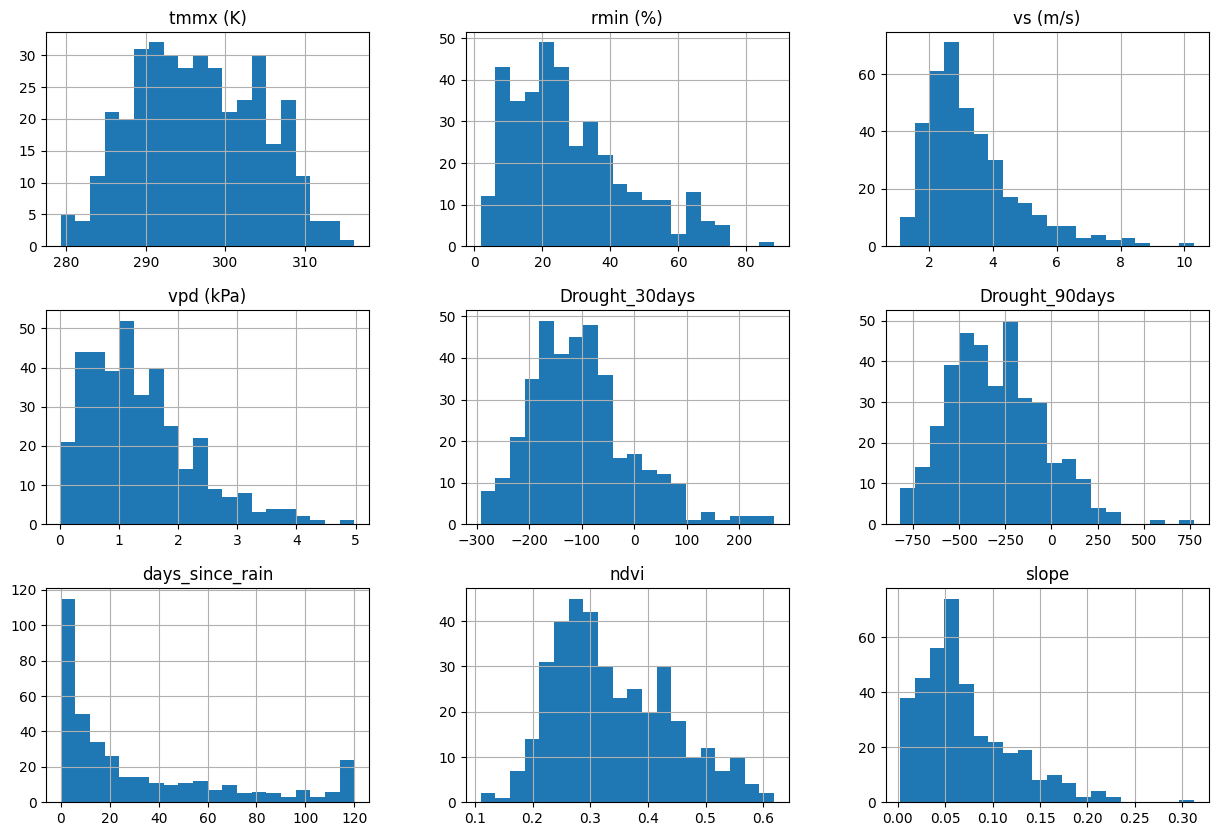

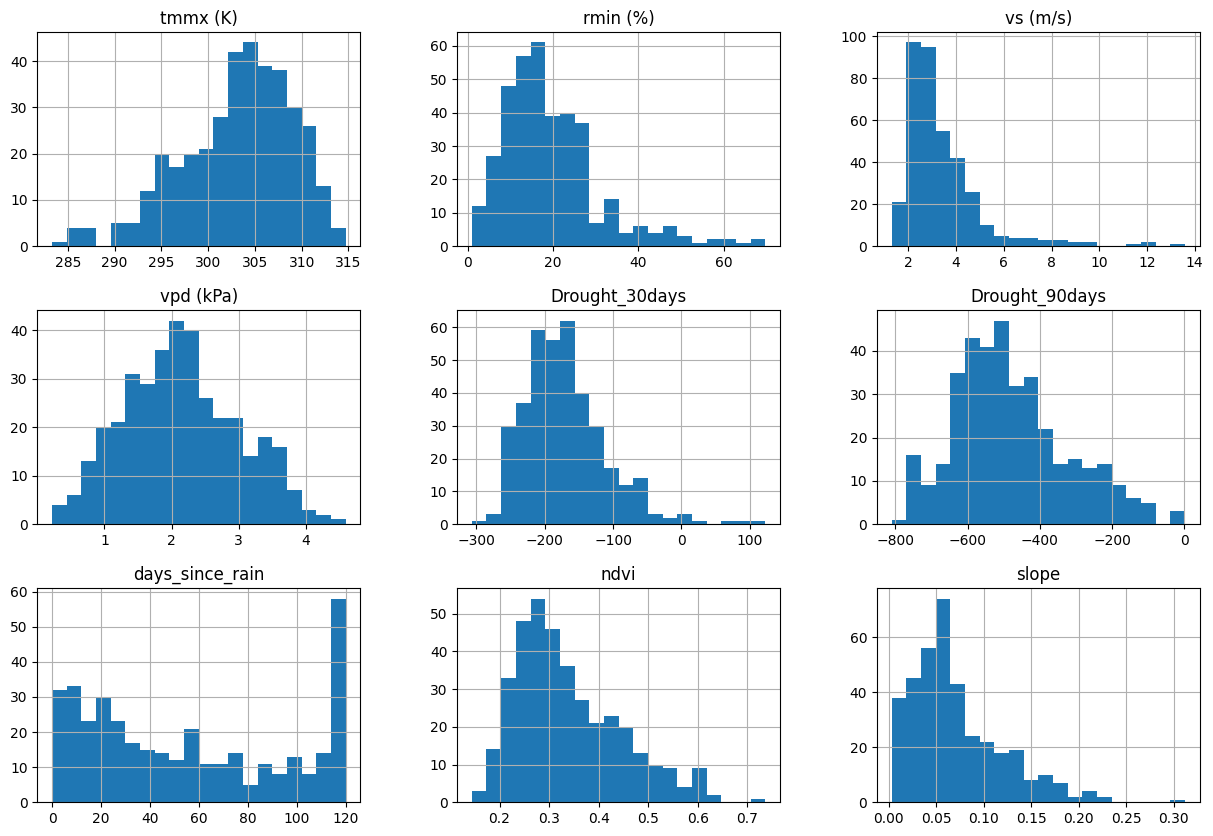

In [ ]:
full_dataset.groupby('label')[['tmmx (K)', 'rmin (%)', 'vs (m/s)', 'vpd (kPa)', 'Drought_30days', 'Drought_90days', 'days_since_rain', 'ndvi', 'slope']].hist(figsize=(15, 10), bins=20)

In [ ]:
full_dataset.groupby('label')[['Drought_90days', 'days_since_rain', 'tmmx (K)', 'rmin (%)', 'ndvi', 'vpd (kPa)']].mean()

,Drought_90days,days_since_rain,tmmx (K),rmin (%),ndvi,vpd (kPa)
label,,,,,,
0,-300.570509,31.538874,296.506166,28.220643,0.338572,1.360965
1,-478.244772,55.265416,303.126810,19.520912,0.339185,2.153807


### Wave 2 — Multivariate (Correlation / Redundancy Check)A single, overall correlation matrix (not split by label) is the right tool for feature-pruning decisions, since redundancy between inputs is a property of the features' physical relationship to each other, not something conditioned on the outcome being predicted. `tmmx`, `rmin`, and `vpd` show strong correlation (expected — VPD is mathematically derived from the other two) but are retained, justified by the fire behavior triangle: they represent physically distinct legs of the weather component, not pure duplication. The per-label version below is a secondary, exploratory check on whether relationships differ by class.

In [ ]:
full_dataset[['Drought_90days', 'days_since_rain', 'tmmx (K)', 'rmin (%)', 'ndvi', 'vpd (kPa)']].corr(numeric_only= True).style.background_gradient(cmap='coolwarm')

,Drought_90days,days_since_rain,tmmx (K),rmin (%),ndvi,vpd (kPa)
Drought_90days,1.000000,-0.597257,-0.666877,0.422633,0.332258,-0.649110
days_since_rain,-0.597257,1.000000,0.493997,-0.236714,-0.114245,0.432108
tmmx (K),-0.666877,0.493997,1.000000,-0.543149,-0.167822,0.898887
rmin (%),0.422633,-0.236714,-0.543149,1.000000,0.304782,-0.709740
ndvi,0.332258,-0.114245,-0.167822,0.304782,1.000000,-0.290088
vpd (kPa),-0.649110,0.432108,0.898887,-0.709740,-0.290088,1.000000


In [ ]:
full_dataset.groupby('label')[['Drought_90days', 'days_since_rain', 'tmmx (K)', 'rmin (%)', 'ndvi', 'vpd (kPa)']].corr(numeric_only= True).style.background_gradient(cmap='coolwarm')

### Bivariate — Santa Ana Flag & Seasonality vs. LabelSanta Ana flag shows a small effect (3.2% of fire days vs. 2.1% of non-fire days) — directionally consistent but limited by a small sample (only 20 of 746 rows are flagged). Month shows a much stronger, clearer signal: fire days cluster heavily in June-September, while non-fire days (randomly sampled) are roughly evenly spread — indicating this dataset predominantly captures the hot/dry *summer* SoCal fire regime rather than the fall/winter Santa Ana-driven regime.

In [ ]:
pd.crosstab(full_dataset['santa_ana_flag'], full_dataset['label'])

label,0,1
santa_ana_flag,,
False,365,361
True,8,12


In [ ]:
pd.crosstab(full_dataset['santa_ana_flag'], full_dataset['label'], normalize='columns')

label,0,1
santa_ana_flag,,
False,0.978552,0.967828
True,0.021448,0.032172


In [ ]:
full_dataset.groupby('label')['month'].value_counts(normalize=True).unstack()

month,1,2,3,4,5,6,7,8,9,10,11,12
label,,,,,,,,,,,,
0,0.075067,0.096515,0.093834,0.093834,0.104558,0.069705,0.096515,0.067024,0.072386,0.061662,0.085791,0.083110
1,0.032172,0.018767,0.013405,0.040214,0.096515,0.152815,0.198391,0.158177,0.134048,0.093834,0.037534,0.024129


## 11. ModelingBaseline logistic regression, compared against a Random Forest to test for non-linear/interaction effects the simpler model can't capture.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

**Feature selection.** Dropped identifiers and non-predictive columns: `fire_name` (an identifier, not a physical quantity), `lat`/`lon` (raw coordinates would let the model memorize specific locations rather than learn the general physical relationships), `date` (too granular to generalize — its useful signal is already captured in `month`), `Drought (mm)` (a single-day intermediate value superseded by the rolled 30/90-day versions), and `cumsum` (internal scaffolding used to compute `days_since_rain`, not a meaningful feature itself).

In [ ]:
drop_col = ['fire_name', 'lat', 'lon', 'date', 'Drought (mm)', 'cumsum', 'label']
X = full_dataset.drop(columns = drop_col)
y = full_dataset['label']

X.columns



Index(['tmmx (K)', 'rmin (%)', 'vs (m/s)', 'vpd (kPa)', 'pr (mm)', 'pet (mm)',
       'erc (-)', 'fm100 (%)', 'fm1000 (%)',
       'th (Degrees clockwise from north)', 'Drought_30days', 'Drought_90days',
       'month', 'days_since_rain', 'santa_ana_flag', 'slope', 'aspect',
       'ndvi'],
      dtype='object')

In [ ]:
y.value_counts()

,count
label,
1,373
0,373


**Train/test split (80/20) and feature scaling.** A random split is used since each row is an independent (location, date) sample rather than one continuous time series. Logistic regression's weighted-sum-plus-gradient-descent training is sensitive to features being on very different scales (e.g. `tmmx` in the 280s-310s vs. `vpd` in the 0-5 range), so `StandardScaler` is fit on the training data only and applied to both train and test — fitting it on test data would leak test-set information into the transformation.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




### Baseline: Logistic Regression

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [ ]:
model.predict(X_test_scaled)

array([1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1])

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7133333333333334
Precision: 0.7160493827160493
Recall: 0.7435897435897436
F1: 0.7295597484276729
Confusion Matrix:
 [[49 23]
 [20 58]]


### Comparison: Random ForestTree-based models split on per-feature thresholds rather than combining features arithmetically, so they don't require scaling (scaling preserves the relative order of values within a feature, which is all a threshold split cares about) — the original, unscaled `X_train`/`X_test` are used directly here.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7466666666666667
Precision: 0.7380952380952381
Recall: 0.7948717948717948
F1: 0.7654320987654321
Confusion Matrix:
 [[50 22]
 [16 62]]


**Result:** every metric improved with the Random Forest (accuracy 0.713 → 0.747, recall 0.744 → 0.795), modest but real evidence of non-linear/interaction effects the additive logistic regression model can't capture. The recall improvement is the most practically meaningful — the Random Forest misses fewer actual fires (16 of 78 vs. 20 of 78).

### Feature ImportanceChecking whether the Random Forest actually relies on the features EDA identified as meaningful.

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False)

,0
pet (mm),0.099330
vpd (kPa),0.092096
tmmx (K),0.090495
Drought_30days,0.085632
Drought_90days,0.082325
ndvi,0.066930
rmin (%),0.058823
erc (-),0.055407
th (Degrees clockwise from north),0.053859
fm100 (%),0.052469


Dryness/drought features (`pet`, `vpd`, `tmmx`, both drought windows) dominate, consistent with the bivariate findings. `ndvi` ranks moderately despite showing almost no difference in its raw mean between fire/non-fire days — suggesting its relationship to fire risk is non-linear or conditional rather than a simple direct one, which only a tree-based model would pick up. `santa_ana_flag` ranks lowest, consistent with the seasonality finding above: this sample is dominated by summer fires rather than the Santa Ana-driven fall regime, so there are too few flagged days for the model to learn much from.

## 12. Prediction Function: A simple, reusable wrapper that takes a raw `(lat, lon, date)` and returns the trained Random Forest's fire-risk prediction and probability — reusing the same feature functions built above.

In [ ]:
def get_prediction(lat, lon, target_date):
  weather_row = get_gritmet_features(lat, lon, target_date)
  slope, aspect = get_slope_aspect(lat, lon)
  ndvi = get_ndvi_feature(lat, lon, target_date)
  combined = weather_row.copy()
  combined['slope'] = slope
  combined['aspect'] = aspect
  combined['ndvi'] = ndvi
  drop_col = ['fire_name', 'lat', 'lon', 'date', 'Drought (mm)', 'cumsum']
  combined = combined.drop(columns=drop_col, errors='ignore')
  prediction = rf_model.predict(combined)
  probability = rf_model.predict_proba(combined)
  return prediction, probability


get_prediction(34.20078476275709, -118.09260810469993, "2025-01-08")



/usr/local/lib/python3.12/dist-packages/pygridmet/pygridmet.py:161: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'day' ('day',) The recommendation is to set join explicitly for this case.
  clm = xr.merge(_open_dataset(f) for f in clm_all_files).astype("f4")
/usr/local/lib/python3.12/dist-packages/pygridmet/pygridmet.py:161: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  clm = xr.merge(_open_dataset(f) for f in clm_all_file

(array([1]), array([[0.15, 0.85]]))